## 1. import dataset

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import random

data_path = "/kaggle/input/datasets/aibloy/fairface/FairFace"
train_csv = "/kaggle/input/datasets/aibloy/fairface/FairFace/train_labels.csv"
val_csv   = "/kaggle/input/datasets/aibloy/fairface/FairFace/val_labels.csv"

train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)

print("Colonnes :", train_df.columns.tolist())
print(f"Train : {len(train_df)} images")
print(f"Val   : {len(val_df)} images")
print(train_df.head(5))

Colonnes : ['file', 'age', 'gender', 'race', 'service_test']
Train : 86744 images
Val   : 10954 images
          file    age  gender        race  service_test
0  train/1.jpg  50-59    Male  East Asian          True
1  train/2.jpg  30-39  Female      Indian         False
2  train/3.jpg    3-9  Female       Black         False
3  train/4.jpg  20-29  Female      Indian          True
4  train/5.jpg  20-29  Female      Indian          True


## 2. Voir la distribution des classes

Distribution Train :
age
20-29           25598
30-39           19250
40-49           10744
3-9             10408
10-19            9103
50-59            6228
60-69            2779
0-2              1792
more than 70      842
Name: count, dtype: int64

Distribution Val :
age
20-29           3300
30-39           2330
3-9             1356
40-49           1353
10-19           1181
50-59            796
60-69            321
0-2              199
more than 70     118
Name: count, dtype: int64


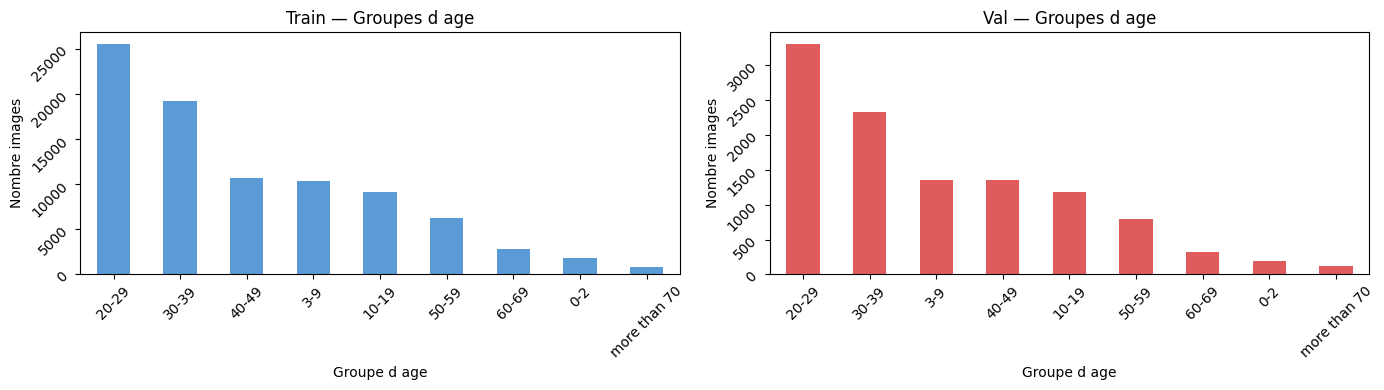

In [2]:
# Distribution des groupes d age — tels quels dans FairFace
distribution     = train_df["age"].value_counts()
distribution_val = val_df["age"].value_counts()

print("Distribution Train :")
print(distribution)
print("\nDistribution Val :")
print(distribution_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

distribution.plot(kind="bar", color="#5B9BD5", ax=axes[0])
axes[0].set_title("Train — Groupes d age")
axes[0].set_xlabel("Groupe d age")
axes[0].set_ylabel("Nombre images")
axes[0].tick_params(rotation=45)

distribution_val.plot(kind="bar", color="#E05C5C", ax=axes[1])
axes[1].set_title("Val — Groupes d age")
axes[1].set_xlabel("Groupe d age")
axes[1].set_ylabel("Nombre images")
axes[1].tick_params(rotation=45)

plt.tight_layout()
plt.show()

## 3. Afficher quelques images pour vérifier visuellement

KeyError: 'chemin'

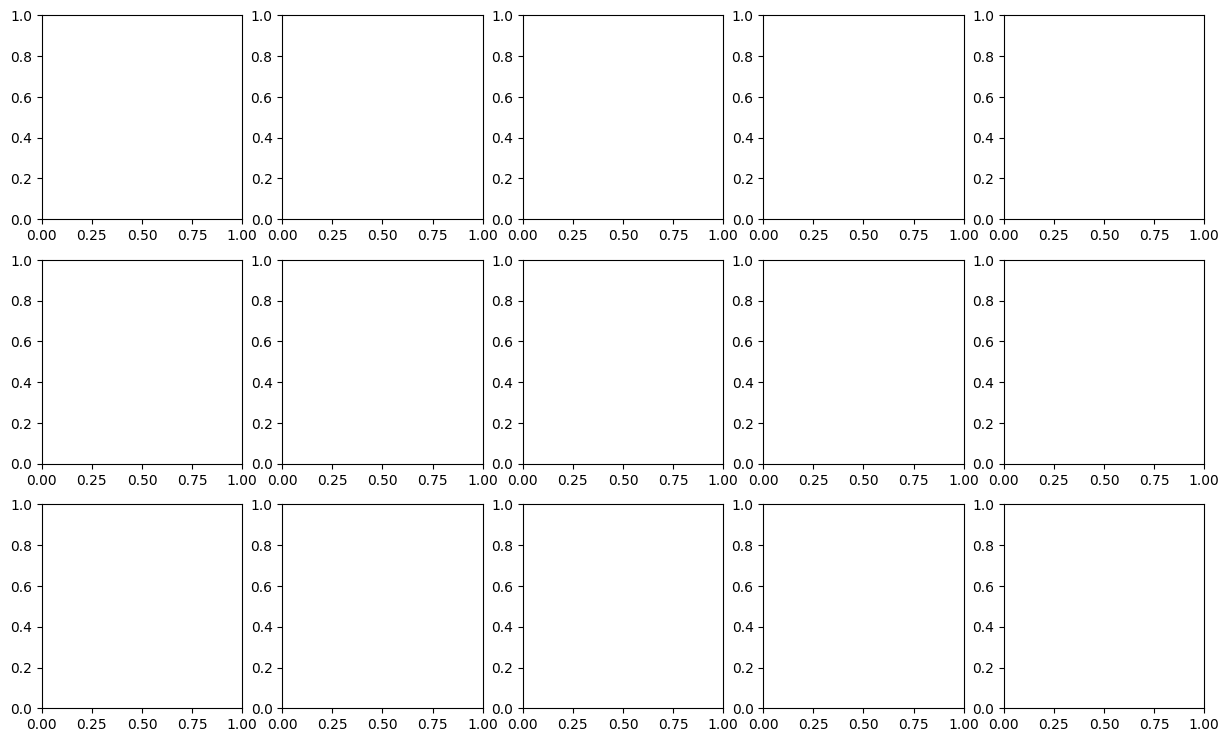

In [3]:
# Afficher 5 images par groupe age
groupes = train_df["age"].unique()[:3]
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for i, groupe in enumerate(groupes):
    exemples = train_df[train_df["age"] == groupe].sample(5)
    for j, (_, row) in enumerate(exemples.iterrows()):
        img = Image.open(row["chemin"])
        axes[i][j].imshow(img)
        axes[i][j].set_title(f"{groupe}")
        axes[i][j].axis("off")

plt.tight_layout()
plt.show()